<a href="https://colab.research.google.com/github/siruku6/parapara-anime/blob/master/notebooks/250102_sample_usage_for_gymnasium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Sample] Visualize the behavior of Gymnasium pendulum-v1

The sample usage of `parapara-anime` is shown below utilizing the env "pendulum-v1" of `gymnasium==1.0.0`.



## 1. Dependencies

You have to install the package `xvfb` for using `parapara-anime`. In addtion to it, `ipython>=8.0.0` is required.

Therefore, the following lines are necessary if you work on Google Colaboratory.


In [1]:
!apt-get -qq -y install xvfb
!pip install -q ipython>=8.0.0 parapara-anime
!pip install -q gymnasium==1.0.0


Selecting previously unselected package libfontenc1:amd64.
(Reading database ... 123634 files and directories currently installed.)
Preparing to unpack .../0-libfontenc1_1%3a1.1.4-1build3_amd64.deb ...
Unpacking libfontenc1:amd64 (1:1.1.4-1build3) ...
Selecting previously unselected package libxfont2:amd64.
Preparing to unpack .../1-libxfont2_1%3a2.0.5-1build1_amd64.deb ...
Unpacking libxfont2:amd64 (1:2.0.5-1build1) ...
Selecting previously unselected package libxkbfile1:amd64.
Preparing to unpack .../2-libxkbfile1_1%3a1.1.0-1build3_amd64.deb ...
Unpacking libxkbfile1:amd64 (1:1.1.0-1build3) ...
Selecting previously unselected package x11-xkb-utils.
Preparing to unpack .../3-x11-xkb-utils_7.7+5build4_amd64.deb ...
Unpacking x11-xkb-utils (7.7+5build4) ...
Selecting previously unselected package xfonts-encodings.
Preparing to unpack .../4-xfonts-encodings_1%3a1.0.5-0ubuntu2_all.deb ...
Unpacking xfonts-encodings (1:1.0.5-0ubuntu2) ...
Selecting previously unselected package xfonts-util

## 2. Import modules

In [3]:
import numpy as np
import gymnasium
from tqdm.notebook import tqdm

from parapara.generator import play_anim


## 3. Visualize the behavior of environment

  0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/usr/local/lib/python3.10/dist-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/envs/classic_control/pendulum.py:218: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = pygame.math.Vector2(c).rotate_rad(self.state[0] + np.pi / 2)


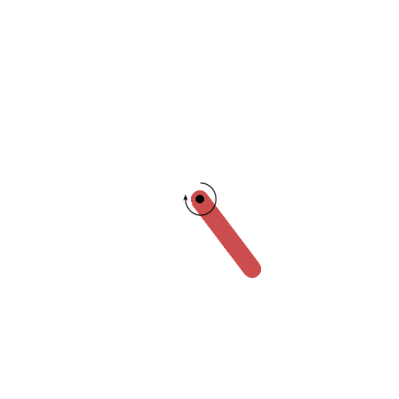

In [6]:
env = gymnasium.make("Pendulum-v1", render_mode="rgb_array")
env.action_space.seed(42)
state, info = env.reset(seed=42)


# The items of an array frames will be visualized.
frames: list[np.ndarray] = []

for _ in tqdm(range(200)):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step([action])
    done = terminated or truncated
    state = observation

    frames.append(env.render())
    if done:
        env.reset()

env.close()


# At last, you have to pass the variable frames into the function `play_anim`
result = play_anim(frames)

# You can visualize the behavior of the Gymnasium environment
# by writing the output of the play_anim function in the last line and running the cell.
result
